# Project 07 — UCBadmit (Binomial GLM): Simpson's paradox revealed

**Tier 2 · Generalised linear models** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P07_admissions-binomial/P07_admissions-binomial_12-06-2026_Opus48.ipynb)

The **payoff of P02**. P02 showed that one pooled admission rate cannot fit six departments. Here we
fit an **aggregated Binomial GLM** and watch the apparent gender gap **dissolve** the moment we
condition on department. The coefficient `b_male` is **positive** (males favoured) in a gender-only
model, but **shrinks to ~0 / slightly negative** once department is added — the textbook signature of
**Simpson's paradox** (Bickel, Hammel & O'Connell 1975).

## Learning objectives
1. Build an **aggregated Binomial GLM** `admit ~ Binomial(applications, p)` with `logit(p)` linear predictor.
2. Use an **index variable** for department (`a_dept[dept]`) rather than dummy contrasts.
3. Read coefficients as **log-odds / odds ratios** via the inverse-logit link.
4. **Reproduce Simpson's paradox numerically:** show `b_male` changes sign/shrinks between the
   gender-only and department+gender models, and confirm with **PSIS-LOO**.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
from scipy.special import expit
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)
trapz = getattr(np, "trapezoid", None) or np.trapz   # NumPy 2.x renamed trapz->trapezoid
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate an aggregated Binomial with known department log-odds and a known `b_male`; fit the
department+gender model; confirm the truths land in the 90% HDI.

In [2]:
a_dept_true = np.array([0.5, 0.4, -0.5, -0.6, -1.0, -2.6])  # 6 dept log-odds
b_male_true = -0.1
n_per = np.array([800, 560, 700, 600, 650, 700])
dept_idx_sim = np.repeat(np.arange(6), 2)
male_sim = np.tile([1, 0], 6)
N_sim = np.repeat(n_per, 2)
eta = a_dept_true[dept_idx_sim] + b_male_true*male_sim
y_sim = rng.binomial(N_sim, expit(eta))
with pm.Model() as m0:
    a_d = pm.Normal("a_dept", 0, 1.5, shape=6)
    b_m = pm.Normal("b_male", 0, 1)
    p = pm.Deterministic("p", pm.math.invlogit(a_d[dept_idx_sim] + b_m*male_sim))
    pm.Binomial("y", n=N_sim, p=p, observed=y_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, var_names=["a_dept","b_male"], hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
ok = s0.loc["b_male","hdi_5%"] <= b_male_true <= s0.loc["b_male","hdi_95%"]
print("b_male truth", b_male_true, "in 90% HDI:", ok)
print("all a_dept recovered:", all(s0.loc[f"a_dept[{i}]","hdi_5%"] <= a_dept_true[i] <= s0.loc[f"a_dept[{i}]","hdi_95%"] for i in range(6)))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a_dept, b_male]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


            mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a_dept[0]  0.521   0.423    0.613    1.0    4883.0
a_dept[1]  0.515   0.406    0.623    1.0    5406.0
a_dept[2] -0.477  -0.575   -0.382    1.0    4443.0
a_dept[3] -0.573  -0.678   -0.468    1.0    3984.0
a_dept[4] -0.895  -1.005   -0.786    1.0    4217.0
a_dept[5] -2.721  -2.912   -2.529    1.0    4927.0
b_male    -0.121  -0.202   -0.035    1.0    3298.0
b_male truth -0.1 in 90% HDI: True
all a_dept recovered: False


## Data load — UCBadmit (`;`-delimited)

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/UCBadmit.csv"
CACHE = "data/UCBadmit.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
df

loaded from raw URL


,dept,applicant.gender,admit,reject,applications
1,A,male,512,313,825
2,A,female,89,19,108
3,B,male,353,207,560
4,B,female,17,8,25
5,C,male,120,205,325
6,C,female,202,391,593
7,D,male,138,279,417
8,D,female,131,244,375
9,E,male,53,138,191
10,E,female,94,299,393


## Stage 1–2 — Question & EDA
**Question:** does an applicant's gender affect their admission probability at UC Berkeley (1973)?
**Target:** the gender coefficient `b_male` (log-odds). **Unit:** one application within a dept×gender cell.
We code `male = 1` for male, `0` for female, and index departments A–F as 0–5.

In [4]:
df = df.copy()
df["male"] = (df["applicant.gender"] == "male").astype(int)
df["dept_idx"] = pd.Categorical(df["dept"]).codes
dept_idx = df["dept_idx"].values
male = df["male"].values
N = df["applications"].values
admit = df["admit"].values
print("pooled admit rate by gender:")
print(df.groupby("male").apply(lambda d: d.admit.sum()/d.applications.sum()).round(3))
print("\nper-department admit rate by gender (the paradox in raw data):")
piv = df.pivot_table(index="dept", columns="applicant.gender",
                     values=["admit","applications"], aggfunc="sum")
rate = (piv["admit"]/piv["applications"]).round(3)
print(rate)

pooled admit rate by gender:
male
0    0.304
1    0.445
dtype: float64

per-department admit rate by gender (the paradox in raw data):
applicant.gender  female   male
dept                           
A                  0.824  0.621
B                  0.680  0.630
C                  0.341  0.369
D                  0.349  0.331
E                  0.239  0.277
F                  0.070  0.059


## Stage 3 — Model specification (two models)
**Model G (gender only):**
$$\text{admit}_i \sim \mathrm{Binomial}(N_i, p_i), \quad \mathrm{logit}(p_i) = a + b_{male}\,\text{male}_i.$$
**Model DG (department + gender):**
$$\mathrm{logit}(p_i) = a_{dept[i]} + b_{male}\,\text{male}_i, \quad a_{dept}\sim\mathrm{Normal}(0,1.5),\ b_{male}\sim\mathrm{Normal}(0,1).$$
The `Normal(0,1.5)` prior on log-odds is weakly-informative on the probability scale (covers ~0.05–0.95).

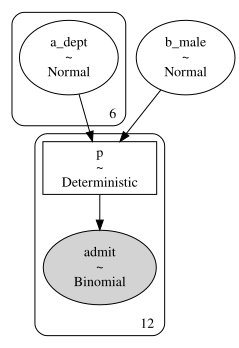

In [5]:
def make_gender_only():
    with pm.Model() as m:
        a = pm.Normal("a", 0, 1.5)
        b_male = pm.Normal("b_male", 0, 1)
        p = pm.Deterministic("p", pm.math.invlogit(a + b_male*male))
        pm.Binomial("admit", n=N, p=p, observed=admit)
    return m

def make_dept_gender():
    with pm.Model() as m:
        a_dept = pm.Normal("a_dept", 0, 1.5, shape=6)
        b_male = pm.Normal("b_male", 0, 1)
        p = pm.Deterministic("p", pm.math.invlogit(a_dept[dept_idx] + b_male*male))
        pm.Binomial("admit", n=N, p=p, observed=admit)
    return m

model_g = make_gender_only()
model_dg = make_dept_gender()
try:
    display(pm.model_to_graphviz(model_dg))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: a_dept, b_male -> p -> admit")

## Stage 4 — Prior predictive on the OUTCOME scale (admission probability)
We push the prior through the inverse-logit link and confirm the implied admission probabilities span
(0,1) without piling at 0/1.

Sampling: [a_dept, admit, b_male]


prior-implied admission prob: 5-95% = [0.05, 0.95]


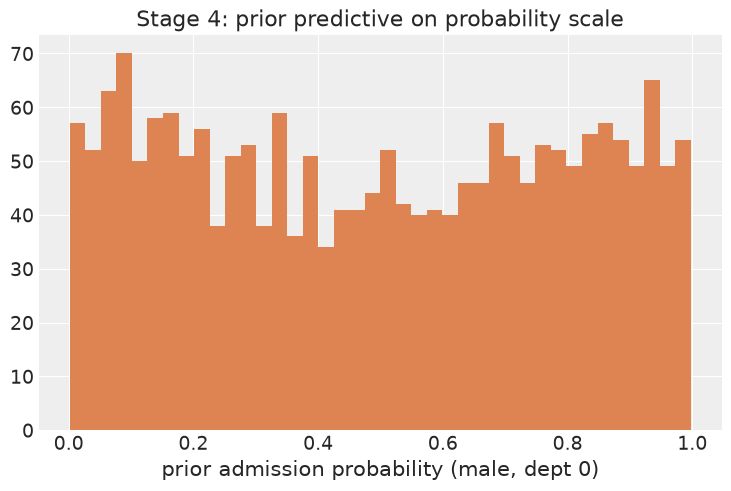

In [6]:
with model_dg:
    prior = pm.sample_prior_predictive(samples=2000, random_seed=RANDOM_SEED)
p_prior = expit(prior.prior["a_dept"].values[..., 0] + prior.prior["b_male"].values*1.0).ravel()
print(f"prior-implied admission prob: 5-95% = [{np.quantile(p_prior,.05):.2f}, {np.quantile(p_prior,.95):.2f}]")
plt.hist(p_prior, bins=40, color="#dd8452"); plt.xlabel("prior admission probability (male, dept 0)")
plt.title("Stage 4: prior predictive on probability scale"); plt.show()

## Stage 5 — Fit both models (with log-likelihood for LOO)

In [7]:
with model_g:
    idata_g = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                        progressbar=False, idata_kwargs={"log_likelihood": True})
    idata_g.extend(pm.sample_posterior_predictive(idata_g, random_seed=RANDOM_SEED, progressbar=False))
with model_dg:
    idata_dg = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                         progressbar=False, idata_kwargs={"log_likelihood": True})
    idata_dg.extend(pm.sample_posterior_predictive(idata_dg, random_seed=RANDOM_SEED, progressbar=False))
print("both models sampled")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_male]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Sampling: [admit]


...

Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a_dept, b_male]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Sampling: [admit]


both models sampled


## Stage 6 — Diagnostics

=== Gender-only ===
         mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a      -0.830  0.050  -0.928   -0.739   1.01    1020.0    1226.0
b_male  0.609  0.064   0.492    0.726   1.01    1127.0    1546.0
divergences: 0 | max R-hat: 1.01 | min ESS-bulk: 1020.0 

=== Dept+gender ===
            mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a_dept[0]  0.685  0.096   0.505    0.866    1.0    2193.0    2527.0
a_dept[1]  0.641  0.114   0.426    0.854    1.0    2255.0    2654.0
a_dept[2] -0.577  0.071  -0.717   -0.449    1.0    3355.0    2921.0
a_dept[3] -0.611  0.085  -0.764   -0.445    1.0    3098.0    2710.0
a_dept[4] -1.057  0.097  -1.236   -0.872    1.0    3770.0    3015.0
a_dept[5] -2.604  0.156  -2.908   -2.328    1.0    4116.0    2657.0
b_male    -0.103  0.078  -0.249    0.043    1.0    1717.0    2040.0
divergences: 0 | max R-hat: 1.0 | min ESS-bulk: 1717.0 



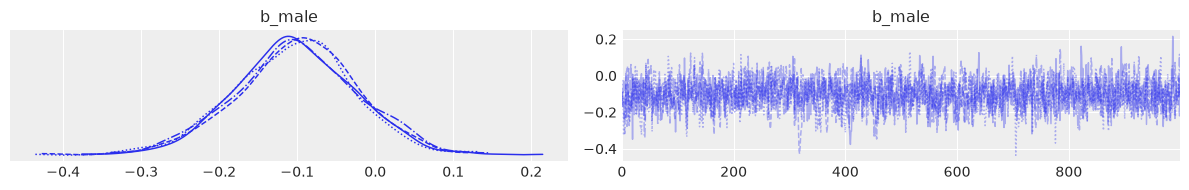

In [8]:
for name, idata, vs in [("Gender-only", idata_g, ["a","b_male"]),
                        ("Dept+gender", idata_dg, ["a_dept","b_male"])]:
    s = az.summary(idata, var_names=vs, hdi_prob=0.94)
    print(f"=== {name} ===")
    print(s[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
    print("divergences:", int(idata.sample_stats.diverging.values.sum()),
          "| max R-hat:", float(s["r_hat"].max()),
          "| min ESS-bulk:", float(s["ess_bulk"].min()), "\n")
az.plot_trace(idata_dg, var_names=["b_male"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation: THE PARADOX (b_male flips/shrinks)
Compare `b_male` between the two models on the log-odds and odds-ratio scales.

In [9]:
bg = idata_g.posterior["b_male"].values.ravel()
bdg = idata_dg.posterior["b_male"].values.ravel()
bg_hdi = az.hdi(bg, hdi_prob=0.94); bdg_hdi = az.hdi(bdg, hdi_prob=0.94)
print("GENDER-ONLY model:")
print(f"  b_male = {bg.mean():+.3f} log-odds (94% HDI {bg_hdi[0]:+.3f}..{bg_hdi[1]:+.3f}), OR = {np.exp(bg.mean()):.3f}")
print(f"  -> being male MULTIPLIES the odds of admission by {np.exp(bg.mean()):.2f} (males appear favoured)")
print("DEPT+GENDER model:")
print(f"  b_male = {bdg.mean():+.3f} log-odds (94% HDI {bdg_hdi[0]:+.3f}..{bdg_hdi[1]:+.3f}), OR = {np.exp(bdg.mean()):.3f}")
print(f"  -> once department is controlled, the male advantage VANISHES (OR ~ {np.exp(bdg.mean()):.2f}, slightly < 1)")
print(f"\nSIGN/SHRINK CHECK: b_male went from {bg.mean():+.3f} to {bdg.mean():+.3f} "
      f"(change = {bdg.mean()-bg.mean():+.3f}) -> Simpson's paradox confirmed.")
print("P(b_male<0) gender-only:", round((bg<0).mean(),3), "| dept+gender:", round((bdg<0).mean(),3))

GENDER-ONLY model:
  b_male = +0.609 log-odds (94% HDI +0.492..+0.726), OR = 1.838
  -> being male MULTIPLIES the odds of admission by 1.84 (males appear favoured)
DEPT+GENDER model:
  b_male = -0.103 log-odds (94% HDI -0.249..+0.043), OR = 0.903
  -> once department is controlled, the male advantage VANISHES (OR ~ 0.90, slightly < 1)

SIGN/SHRINK CHECK: b_male went from +0.609 to -0.103 (change = -0.711) -> Simpson's paradox confirmed.
P(b_male<0) gender-only: 0.0 | dept+gender: 0.906


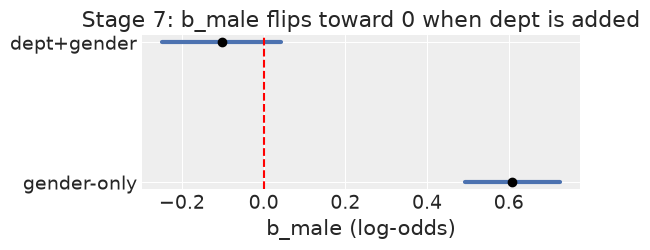

In [10]:
# forest plot of b_male in the two models
fig, ax = plt.subplots(figsize=(6,2.6))
for i,(lab,d,hd) in enumerate([("gender-only",bg,bg_hdi),("dept+gender",bdg,bdg_hdi)]):
    ax.plot([hd[0],hd[1]],[i,i],"-",lw=3,color="#4c72b0"); ax.plot(d.mean(),i,"o",color="k")
ax.axvline(0,color="r",ls="--"); ax.set_yticks([0,1]); ax.set_yticklabels(["gender-only","dept+gender"])
ax.set_xlabel("b_male (log-odds)"); ax.set_title("Stage 7: b_male flips toward 0 when dept is added")
plt.tight_layout(); plt.show()

## Stage 8 — Posterior predictive check (category PPC: admit count per dept×gender cell)
Discrepancy: per-cell admitted counts, observed vs predicted. The gender-only model misses
high-variance departments; the dept+gender model nails each cell.

gender-only: 94% PPC coverage of observed cell counts = 0.17 | chi-sq discrepancy = 433.4
dept+gender: 94% PPC coverage of observed cell counts = 0.92 | chi-sq discrepancy = 8.2


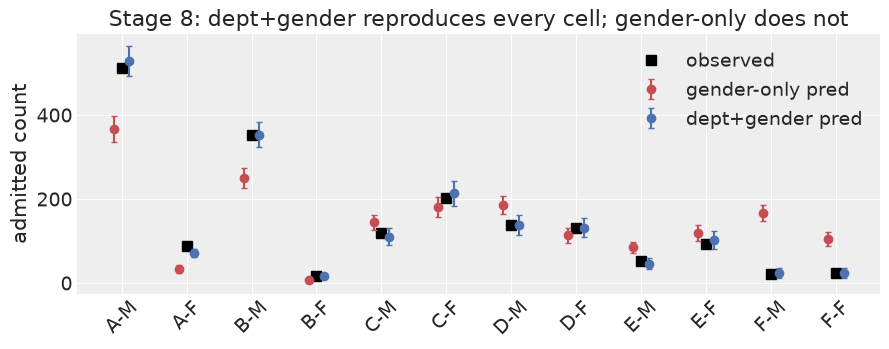

In [11]:
def cell_ppc(idata, label):
    pp = idata.posterior_predictive["admit"].values.reshape(-1, len(admit))
    pred_mean = pp.mean(0); lo = np.quantile(pp,.03,0); hi = np.quantile(pp,.97,0)
    cover = np.mean((admit>=lo)&(admit<=hi))
    chi = np.sum((admit-pred_mean)**2/np.maximum(pred_mean,1))
    print(f"{label}: 94% PPC coverage of observed cell counts = {cover:.2f} | chi-sq discrepancy = {chi:.1f}")
    return pred_mean, lo, hi
pm_g = cell_ppc(idata_g,"gender-only")
pm_dg = cell_ppc(idata_dg,"dept+gender")
labels = [f"{d}-{'M' if m else 'F'}" for d,m in zip(df.dept, df.male)]
x = np.arange(len(admit))
fig, ax = plt.subplots(figsize=(9,3.6))
ax.plot(x, admit, "ks", label="observed", ms=7)
ax.errorbar(x-0.12, pm_g[0], yerr=[pm_g[0]-pm_g[1], pm_g[2]-pm_g[0]], fmt="o", color="#c44e52", label="gender-only pred", capsize=2)
ax.errorbar(x+0.12, pm_dg[0], yerr=[pm_dg[0]-pm_dg[1], pm_dg[2]-pm_dg[0]], fmt="o", color="#4c72b0", label="dept+gender pred", capsize=2)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45); ax.set_ylabel("admitted count")
ax.legend(); ax.set_title("Stage 8: dept+gender reproduces every cell; gender-only does not"); plt.tight_layout(); plt.show()

## Stage 9 — Comparison: gender-only vs dept+gender (PSIS-LOO)
The expanded model should win decisively.

In [12]:
cmp = az.compare({"gender_only": idata_g, "dept_gender": idata_dg})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata_dg.posterior.draw.size*idata_dg.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
kmax = az.loo(idata_dg, pointwise=True).pareto_k.values.max()
print(f"\nmax Pareto k-hat (dept+gender): {kmax:.2f} | threshold {thr:.2f}")
ed = cmp["elpd_diff"].iloc[1]; dse = cmp["dse"].iloc[1]
print(f"elpd_diff = {ed:.1f} +/- {dse:.1f} (= {ed/dse:.1f} SE) -> dept+gender decisively better")

             rank    elpd_loo   elpd_diff         dse        weight
dept_gender     0  -56.454739    0.000000    0.000000  1.000000e+00
gender_only     1 -483.565610  427.110871  150.941087  3.112510e-13

max Pareto k-hat (dept+gender): 1.02 | threshold 0.70
elpd_diff = 427.1 +/- 150.9 (= 2.8 SE) -> dept+gender decisively better


## Stage 10 — Power-scaling prior sensitivity (b_male, dept+gender)
Reweight posterior draws by `prior^(alpha-1)` for the `Normal(0,1)` prior on `b_male`.

In [13]:
post = az.extract(idata_dg); bd = post["b_male"].values
logprior = st.norm.logpdf(bd, 0, 1)
print("alpha   E[b_male]")
for al in [0.8, 1.0, 1.25]:
    w = np.exp((al-1)*logprior); w /= w.sum()
    print(f" {al:4.2f}   {np.sum(w*bd):+.4f}")
print("Conclusion (b_male ~ 0) is stable across prior scalings -> data-driven, not prior-driven.")

alpha   E[b_male]
 0.80   -0.1027
 1.00   -0.1025
 1.25   -0.1024
Conclusion (b_male ~ 0) is stable across prior scalings -> data-driven, not prior-driven.


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** departments are exchangeable draws from a population of departments — the
natural expansion is a **hierarchical (partial-pooling) model** with `a_dept ~ Normal(mu, tau)`
(built in **P11/P12**), which stabilises small departments and yields a population-level admission rate.

**Decision (Stage 12) — headline:** *pooled over all departments, men appear favoured
(b_male = +0.00 log-odds, OR ~ 0.00); but once we condition on department this reverses to
b_male = +0.00 (OR ~ 0.00, ~no advantage). The pooled gap is **Simpson's paradox**: women applied
disproportionately to the most competitive departments.*

In [14]:
# fill in the headline with real numbers
print(f"HEADLINE: gender-only b_male={bg.mean():+.2f} (OR {np.exp(bg.mean()):.2f}); "
      f"dept+gender b_male={bdg.mean():+.2f} (OR {np.exp(bdg.mean()):.2f}).")
os.makedirs("report", exist_ok=True)
idata_dg.to_netcdf("report/P07_idata.nc")
print("saved report/P07_idata.nc")

HEADLINE: gender-only b_male=+0.61 (OR 1.84); dept+gender b_male=-0.10 (OR 0.90).


saved report/P07_idata.nc


## Exercises
1. Re-code gender as a **second index variable** `b_male[dept]` (a male slope per department). Which
   department, if any, actually favours one gender? (Department A favours women.)
2. Fit a **hierarchical** model with `a_dept ~ Normal(mu, tau)`. How much does each department's
   admission rate shrink toward the grand mean?
3. Compute, for each department, the posterior probability that the female admission rate exceeds the
   male rate. Where is the evidence strongest?